# Exercise 1b, 1c

in the following exercise, we make use of the given function heat_forward

In [2]:
import numpy as np
from scipy.fft import dct, idct
from matplotlib import pyplot as plt


def heat_forward(x, T):
    """Apply K on the midpoint grid s_i = (i-1/2)*pi/n."""
    j = np.arange(len(x))
    c = dct(x, type=2, norm='ortho') # cosine coefficients
    return idct(np.exp(-T * j**2) * c, type=2, norm='ortho')


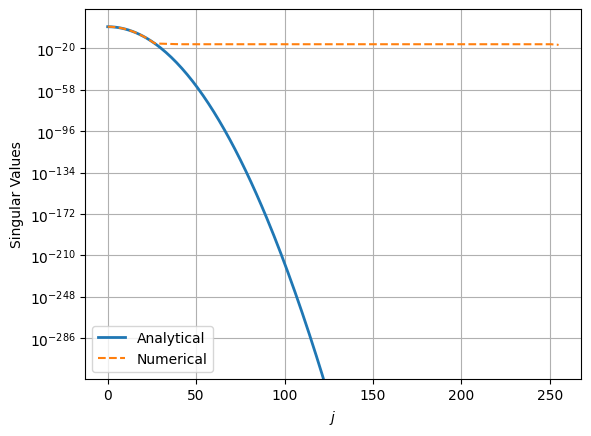

In [ ]:
#Computing the timesteps
T = 0.05
n = 256
h = np.pi/n

#Initializing and constructing A
A = np.zeros((n,n))

for i in range(n):
    x = np.zeros(n)
    x[i] = 1
    A[:,i] = heat_forward(x, T)

#Comparison between the analytical and numerical singular values of A
U, sigmaj, Vt = np.linalg.svd(A)
j_idx = np.arange(n)
muj = np.exp(-T * j_idx**2)

plt.semilogy(j_idx, muj, label='Analytical', linewidth=2)
plt.semilogy(j_idx, sigmaj, label='Numerical', linestyle='--')
plt.xlabel('$j$')
plt.ylabel('Singular Values')
plt.legend()
plt.grid(True)
plt.show()


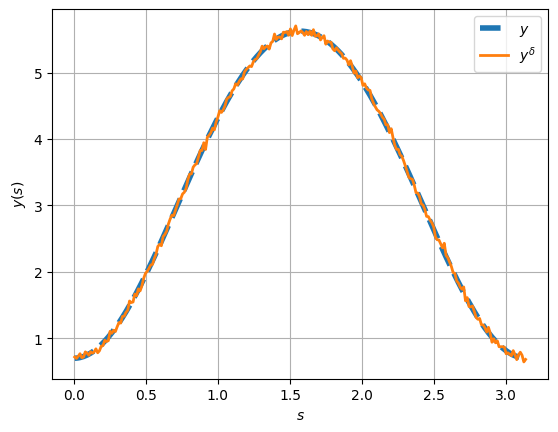

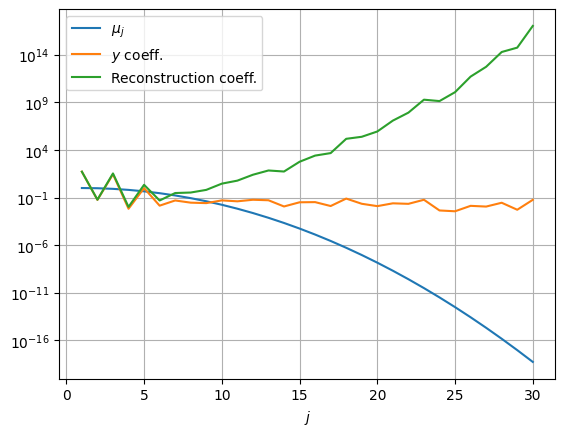

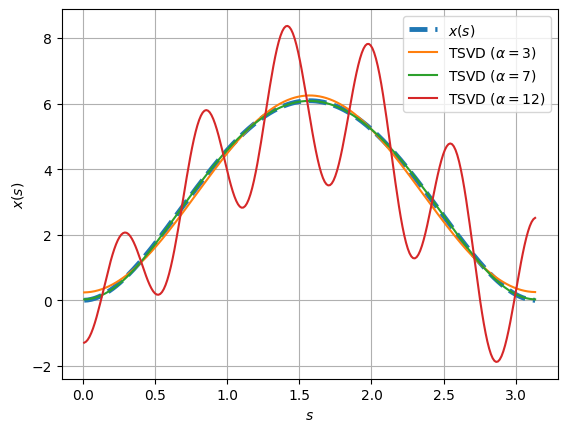

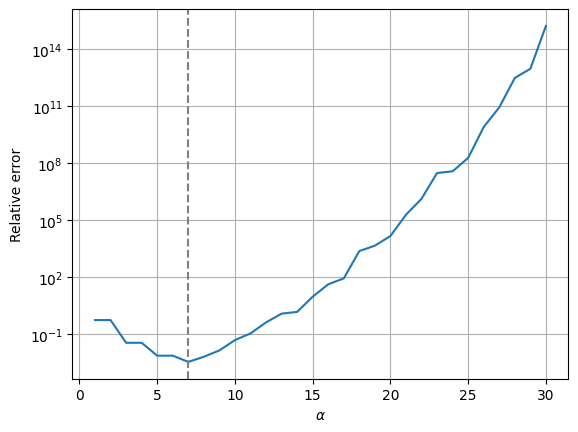

In [ ]:
#Defining the function x(s) and applying the discrete operator to obtain y
s = (np.arange(1,n+1) - 1/2) *h
x = lambda s : s**2 * (np.pi - s)**2
x_vec = np.zeros(n)
x_vec[:] = x(s)
Kx = heat_forward(x_vec, T)

#Adding noise to y
np.random.seed(42)
d = np.random.randn(n)
d = d / np.linalg.norm(d) * 0.01 * np.linalg.norm(Kx)
y_delta = Kx + d

plt.plot(s, Kx, label='$y$', linewidth=4, linestyle='--')
plt.plot(s, y_delta, label='$y^\\delta$', linewidth=2)
plt.xlabel('$s$')
plt.ylabel('$y(s)$')
plt.legend()
plt.grid(True)
plt.show()

# computing the coefficients (ignoring overflow errors)
c = dct(y_delta, type=2, norm='ortho')
abs_c = np.abs(c)
coeff = np.zeros(n)
abs_coeff = np.zeros(n)
with np.errstate(all='ignore'):
    coeff = c / muj
    abs_coeff = abs_c / muj

#Picard plot (only the first indices)
limit = 30
plt.semilogy(np.arange(1,30+1), muj[:30], label='$\\mu_j$')
plt.semilogy(np.arange(1,30+1), abs_c[:30], label='$y$ coeff.')
plt.semilogy(np.arange(1,30+1), abs_coeff[:30], label='Reconstruction coeff.')
plt.xlabel('$j$')
plt.legend()
plt.grid(True)
plt.show()

#Reconstructing x for different values of alpha
alphas = np.arange(1,limit+1)
errors = np.zeros(limit)
plt.plot(s, x_vec, label='$x(s)$', linestyle='--', linewidth=3.5)

for alpha in alphas:
    coeff_tsvd = np.zeros(n)
    coeff_tsvd[:alpha] = coeff[:alpha]
    x_cap = idct(coeff_tsvd, type=2, norm='ortho')
    errors[alpha-1] = np.linalg.norm(x_cap-x_vec) / np.linalg.norm(x_vec)
    if alpha in [3,7,12]:
        plt.plot(s, x_cap, label=f'TSVD ($\\alpha ={alpha}$)', linewidth=1.5)

plt.xlabel('$s$')
plt.ylabel('$x(s)$')
plt.legend()
plt.grid(True)
plt.show()

plt.semilogy(alphas, errors)
plt.axvline(np.argmin(errors)+1, linestyle='--', color='grey')
plt.xlabel('$\\alpha$')
plt.ylabel('Relative error')
plt.grid(True)
plt.show()

